Using device: cuda
Epoch [1/100], Loss: 0.8048
Epoch [2/100], Loss: 0.5492
Epoch [3/100], Loss: 0.4708
Epoch [4/100], Loss: 0.4237
Epoch [5/100], Loss: 0.3981
Epoch [6/100], Loss: 0.3730
Epoch [7/100], Loss: 0.3595
Epoch [8/100], Loss: 0.3405
Epoch [9/100], Loss: 0.3249
Epoch [10/100], Loss: 0.3084
Epoch [11/100], Loss: 0.3004
Epoch [12/100], Loss: 0.2884
Epoch [13/100], Loss: 0.2782
Epoch [14/100], Loss: 0.2723
Epoch [15/100], Loss: 0.2626
Epoch [16/100], Loss: 0.2552
Epoch [17/100], Loss: 0.2487
Epoch [18/100], Loss: 0.2441
Epoch [19/100], Loss: 0.2393
Epoch [20/100], Loss: 0.2350
Epoch [21/100], Loss: 0.2308
Epoch [22/100], Loss: 0.2235
Epoch [23/100], Loss: 0.2194
Epoch [24/100], Loss: 0.2188
Epoch [25/100], Loss: 0.2154
Epoch [26/100], Loss: 0.2090
Epoch [27/100], Loss: 0.2066
Epoch [28/100], Loss: 0.2019
Epoch [29/100], Loss: 0.2018
Epoch [30/100], Loss: 0.1964
Epoch [31/100], Loss: 0.1936
Epoch [32/100], Loss: 0.1917
Epoch [33/100], Loss: 0.1886
Epoch [34/100], Loss: 0.1858
Epoc

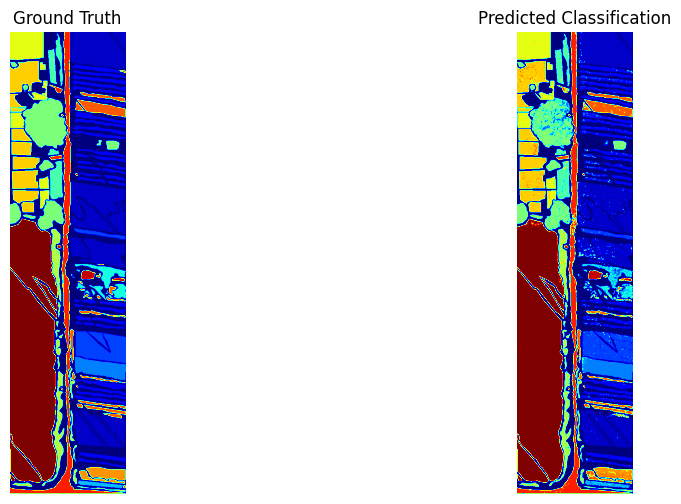

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from torch.cuda.amp import autocast, GradScaler

# ------------------------------
# Data Loading and Preprocessing
# ------------------------------
# Load Salinas hyperspectral data and ground truth
data_dict = sio.loadmat('./Data/WHU_Hi_HanChuan.mat')
gt_dict = sio.loadmat('./Data/WHU_Hi_HanChuan_gt.mat')

# Assume variable names in .mat files
data_cube = data_dict['WHU_Hi_HanChuan']  # shape: (height, width, num_bands)
gt = gt_dict['WHU_Hi_HanChuan_gt']         # shape: (height, width)

# Extract pixels with valid ground truth (label > 0)
indices = np.where(gt > 0)  # tuple of (row_indices, col_indices)
X_all = data_cube[indices]  # shape: (num_samples, num_bands)
y_all = gt[indices].astype(np.int64) - 1  # convert to 0-indexed labels

num_bands = data_cube.shape[2]

# Split into training and testing sets
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, y_all, np.arange(X_all.shape[0]), test_size=0.3, random_state=42, stratify=y_all
)

# Convert arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.long)
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
y_all_tensor = torch.tensor(y_all, dtype=torch.long)

# For 2D CNN, we simulate a spatial patch.
# Here we create a patch by unsqueezing and repeating each spectral vector.
patch_size = 20
X_train = X_train.unsqueeze(2).unsqueeze(3).expand(-1, -1, patch_size, patch_size)
X_test  = X_test.unsqueeze(2).unsqueeze(3).expand(-1, -1, patch_size, patch_size)
X_all_tensor = X_all_tensor.unsqueeze(2).unsqueeze(3).expand(-1, -1, patch_size, patch_size)


# Create DataLoader objects
batch_size = 256
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)
train_loader  = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader   = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# ------------------------------
# Define 2D CNN Model with 7 Convolution Layers
# ------------------------------
class Hyperspectral2DCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Hyperspectral2DCNN, self).__init__()
        # Define 7 convolution layers, each with kernel size 3 and padding 1.
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.conv6 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.conv7 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        # Use MaxPool2d to downsample.
        # We add pooling layers after conv2, conv4, and conv6.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # After three poolings, spatial size reduces from 16 to 16/8 = 2.
        self.fc = nn.Sequential(
            nn.Linear(512 * 2 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        # x shape: (batch_size, in_channels, H, W)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.pool(x)  # spatial dims: 16 -> 8
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool(x)  # spatial dims: 8 -> 4
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.pool(x)  # spatial dims: 4 -> 2
        x = self.conv7(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# ------------------------------
# Setup Training Parameters and Mixed Precision
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = int(y_all.max() + 1)
learning_rate = 0.001
num_epochs = 100

model = Hyperspectral2DCNN(in_channels=num_bands, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scaler = GradScaler()  # For mixed precision training

# ------------------------------
# Training Loop with Mixed Precision
# ------------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# ------------------------------
# Evaluation on Test Set with Mixed Precision
# ------------------------------
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        with autocast():
            outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# ------------------------------
# Inference on Entire Dataset for Visualization (in Mini-batches)
# ------------------------------
model.eval()
inference_batch_size = 16
preds_all = []
with torch.no_grad():
    for i in range(0, X_all_tensor.size(0), inference_batch_size):
        batch = X_all_tensor[i:i+inference_batch_size].to(device)
        with autocast():
            outputs = model(batch)
        _, predicted = torch.max(outputs, 1)
        preds_all.append(predicted.cpu())
        torch.cuda.empty_cache()
preds_all = torch.cat(preds_all, dim=0).numpy()

# Reconstruct predicted classification image for valid pixels
pred_map = np.zeros_like(gt, dtype=np.int32)
pred_map[indices] = preds_all + 1  # Convert back to 1-indexed for visualization
gt_map = np.zeros_like(gt, dtype=np.int32)
gt_map[indices] = y_all + 1

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(gt_map, cmap='jet')
plt.title("Ground Truth")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(pred_map, cmap='jet')
plt.title("Predicted Classification")
plt.axis('off')
plt.show()


In [7]:
# Evaluation on Test Set with Mixed Precision
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        with autocast():
            outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Compute overall metrics
overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
# Compute class-wise accuracy: diagonal elements divided by row sums of confusion matrix
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)

print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# Print class-wise accuracies
for i, acc in enumerate(class_acc):
    print(f"Accuracy for class {i}: {acc:.4f}")


Overall Accuracy: 0.9373
Average Accuracy: 0.8743
Kappa Score: 0.9265
Accuracy for class 0: 0.9749
Accuracy for class 1: 0.9251
Accuracy for class 2: 0.9154
Accuracy for class 3: 0.9595
Accuracy for class 4: 0.7139
Accuracy for class 5: 0.6890
Accuracy for class 6: 0.8910
Accuracy for class 7: 0.8244
Accuracy for class 8: 0.9113
Accuracy for class 9: 0.9575
Accuracy for class 10: 0.9570
Accuracy for class 11: 0.7047
Accuracy for class 12: 0.8018
Accuracy for class 13: 0.9355
Accuracy for class 14: 0.8328
Accuracy for class 15: 0.9947


# HongHu Dataset

Using device: cuda
Epoch [1/100], Loss: 0.7369
Epoch [2/100], Loss: 0.5523
Epoch [3/100], Loss: 0.5023
Epoch [4/100], Loss: 0.4734
Epoch [5/100], Loss: 0.4557
Epoch [6/100], Loss: 0.4383
Epoch [7/100], Loss: 0.4257
Epoch [8/100], Loss: 0.4080
Epoch [9/100], Loss: 0.3937
Epoch [10/100], Loss: 0.3779
Epoch [11/100], Loss: 0.3661
Epoch [12/100], Loss: 0.3562
Epoch [13/100], Loss: 0.3467
Epoch [14/100], Loss: 0.3391
Epoch [15/100], Loss: 0.3318
Epoch [16/100], Loss: 0.3251
Epoch [17/100], Loss: 0.3176
Epoch [18/100], Loss: 0.3135
Epoch [19/100], Loss: 0.3077
Epoch [20/100], Loss: 0.3031
Epoch [21/100], Loss: 0.2992
Epoch [22/100], Loss: 0.2949
Epoch [23/100], Loss: 0.2921
Epoch [24/100], Loss: 0.2881
Epoch [25/100], Loss: 0.2846
Epoch [26/100], Loss: 0.2813
Epoch [27/100], Loss: 0.2783
Epoch [28/100], Loss: 0.2747
Epoch [29/100], Loss: 0.2715
Epoch [30/100], Loss: 0.2690
Epoch [31/100], Loss: 0.2653
Epoch [32/100], Loss: 0.2650
Epoch [33/100], Loss: 0.2612
Epoch [34/100], Loss: 0.2567
Epoc

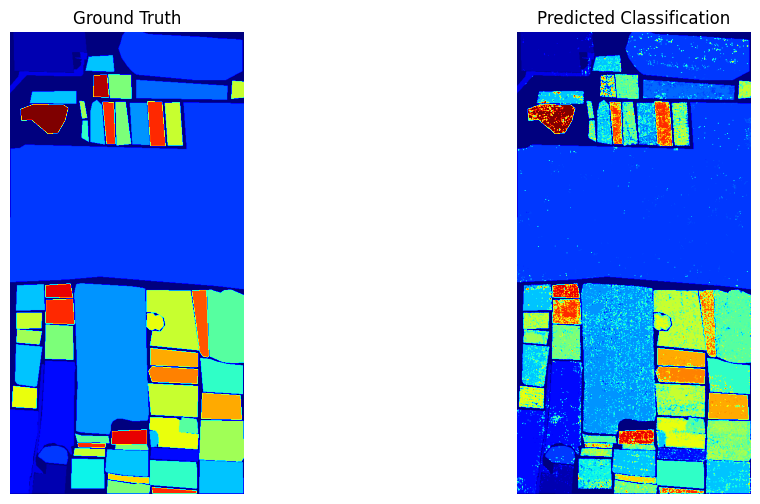

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from torch.cuda.amp import autocast, GradScaler

# ------------------------------
# Data Loading and Preprocessing
# ------------------------------
# Load Salinas hyperspectral data and ground truth
data_dict = sio.loadmat('./Data/WHU_Hi_HongHu.mat')
gt_dict = sio.loadmat('./Data/WHU_Hi_HongHu_gt.mat')

# Assume variable names in .mat files
data_cube = data_dict['WHU_Hi_HongHu']  # shape: (height, width, num_bands)
gt = gt_dict['WHU_Hi_HongHu_gt']         # shape: (height, width)

# Extract pixels with valid ground truth (label > 0)
indices = np.where(gt > 0)  # tuple of (row_indices, col_indices)
X_all = data_cube[indices]  # shape: (num_samples, num_bands)
y_all = gt[indices].astype(np.int64) - 1  # convert to 0-indexed labels

num_bands = data_cube.shape[2]

# Split into training and testing sets
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, y_all, np.arange(X_all.shape[0]), test_size=0.3, random_state=42, stratify=y_all
)

# Convert arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.long)
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
y_all_tensor = torch.tensor(y_all, dtype=torch.long)

# For 2D CNN, we simulate a spatial patch.
# Here we create a patch by unsqueezing and repeating each spectral vector.
patch_size = 20
X_train = X_train.unsqueeze(2).unsqueeze(3).expand(-1, -1, patch_size, patch_size)
X_test  = X_test.unsqueeze(2).unsqueeze(3).expand(-1, -1, patch_size, patch_size)
X_all_tensor = X_all_tensor.unsqueeze(2).unsqueeze(3).expand(-1, -1, patch_size, patch_size)


# Create DataLoader objects
batch_size = 256
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)
train_loader  = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader   = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# ------------------------------
# Define 2D CNN Model with 7 Convolution Layers
# ------------------------------
class Hyperspectral2DCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Hyperspectral2DCNN, self).__init__()
        # Define 7 convolution layers, each with kernel size 3 and padding 1.
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.conv6 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.conv7 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        # Use MaxPool2d to downsample.
        # We add pooling layers after conv2, conv4, and conv6.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # After three poolings, spatial size reduces from 16 to 16/8 = 2.
        self.fc = nn.Sequential(
            nn.Linear(512 * 2 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        # x shape: (batch_size, in_channels, H, W)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.pool(x)  # spatial dims: 16 -> 8
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool(x)  # spatial dims: 8 -> 4
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.pool(x)  # spatial dims: 4 -> 2
        x = self.conv7(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# ------------------------------
# Setup Training Parameters and Mixed Precision
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = int(y_all.max() + 1)
learning_rate = 0.001
num_epochs = 100

model = Hyperspectral2DCNN(in_channels=num_bands, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scaler = GradScaler()  # For mixed precision training

# ------------------------------
# Training Loop with Mixed Precision
# ------------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# ------------------------------
# Evaluation on Test Set with Mixed Precision
# ------------------------------
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        with autocast():
            outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# ------------------------------
# Inference on Entire Dataset for Visualization (in Mini-batches)
# ------------------------------
model.eval()
inference_batch_size = 16
preds_all = []
with torch.no_grad():
    for i in range(0, X_all_tensor.size(0), inference_batch_size):
        batch = X_all_tensor[i:i+inference_batch_size].to(device)
        with autocast():
            outputs = model(batch)
        _, predicted = torch.max(outputs, 1)
        preds_all.append(predicted.cpu())
        torch.cuda.empty_cache()
preds_all = torch.cat(preds_all, dim=0).numpy()

# Reconstruct predicted classification image for valid pixels
pred_map = np.zeros_like(gt, dtype=np.int32)
pred_map[indices] = preds_all + 1  # Convert back to 1-indexed for visualization
gt_map = np.zeros_like(gt, dtype=np.int32)
gt_map[indices] = y_all + 1

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(gt_map, cmap='jet')
plt.title("Ground Truth")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(pred_map, cmap='jet')
plt.title("Predicted Classification")
plt.axis('off')
plt.show()


In [9]:
# Evaluation on Test Set with Mixed Precision
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        with autocast():
            outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Compute overall metrics
overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
# Compute class-wise accuracy: diagonal elements divided by row sums of confusion matrix
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)

print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# Print class-wise accuracies
for i, acc in enumerate(class_acc):
    print(f"Accuracy for class {i}: {acc:.4f}")


Overall Accuracy: 0.8871
Average Accuracy: 0.7694
Kappa Score: 0.8567
Accuracy for class 0: 0.9736
Accuracy for class 1: 0.8691
Accuracy for class 2: 0.9268
Accuracy for class 3: 0.9878
Accuracy for class 4: 0.7684
Accuracy for class 5: 0.8718
Accuracy for class 6: 0.8363
Accuracy for class 7: 0.5271
Accuracy for class 8: 0.9467
Accuracy for class 9: 0.7746
Accuracy for class 10: 0.6982
Accuracy for class 11: 0.4628
Accuracy for class 12: 0.7675
Accuracy for class 13: 0.7367
Accuracy for class 14: 0.8239
Accuracy for class 15: 0.9188
Accuracy for class 16: 0.8206
Accuracy for class 17: 0.5876
Accuracy for class 18: 0.6955
Accuracy for class 19: 0.8356
Accuracy for class 20: 0.2739
Accuracy for class 21: 0.8234


# LongKou Dataset

Using device: cuda
Epoch [1/100], Loss: 0.2545
Epoch [2/100], Loss: 0.1352
Epoch [3/100], Loss: 0.0980
Epoch [4/100], Loss: 0.0874
Epoch [5/100], Loss: 0.0765
Epoch [6/100], Loss: 0.0665
Epoch [7/100], Loss: 0.0583
Epoch [8/100], Loss: 0.0545
Epoch [9/100], Loss: 0.0501
Epoch [10/100], Loss: 0.0483
Epoch [11/100], Loss: 0.0431
Epoch [12/100], Loss: 0.0438
Epoch [13/100], Loss: 0.0436
Epoch [14/100], Loss: 0.0387
Epoch [15/100], Loss: 0.0354
Epoch [16/100], Loss: 0.0340
Epoch [17/100], Loss: 0.0362
Epoch [18/100], Loss: 0.0359
Epoch [19/100], Loss: 0.0309
Epoch [20/100], Loss: 0.0301
Epoch [21/100], Loss: 0.0285
Epoch [22/100], Loss: 0.0291
Epoch [23/100], Loss: 0.0284
Epoch [24/100], Loss: 0.0274
Epoch [25/100], Loss: 0.0245
Epoch [26/100], Loss: 0.0264
Epoch [27/100], Loss: 0.0266
Epoch [28/100], Loss: 0.0244
Epoch [29/100], Loss: 0.0247
Epoch [30/100], Loss: 0.0232
Epoch [31/100], Loss: 0.0235
Epoch [32/100], Loss: 0.0214
Epoch [33/100], Loss: 0.0219
Epoch [34/100], Loss: 0.0209
Epoc

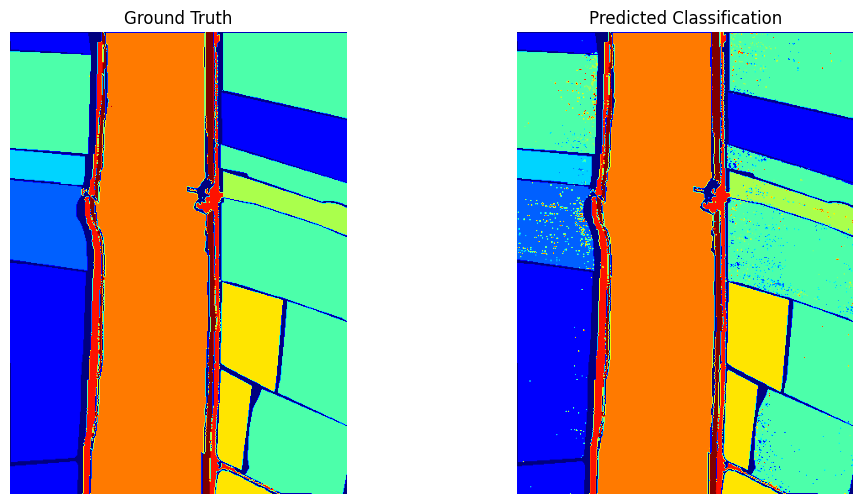

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from torch.cuda.amp import autocast, GradScaler

# ------------------------------
# Data Loading and Preprocessing
# ------------------------------
# Load Salinas hyperspectral data and ground truth
data_dict = sio.loadmat('./Data/WHU_Hi_LongKou.mat')
gt_dict = sio.loadmat('./Data/WHU_Hi_LongKou_gt.mat')

# Assume variable names in .mat files
data_cube = data_dict['WHU_Hi_LongKou']  # shape: (height, width, num_bands)
gt = gt_dict['WHU_Hi_LongKou_gt']         # shape: (height, width)

# Extract pixels with valid ground truth (label > 0)
indices = np.where(gt > 0)  # tuple of (row_indices, col_indices)
X_all = data_cube[indices]  # shape: (num_samples, num_bands)
y_all = gt[indices].astype(np.int64) - 1  # convert to 0-indexed labels

num_bands = data_cube.shape[2]

# Split into training and testing sets
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, y_all, np.arange(X_all.shape[0]), test_size=0.3, random_state=42, stratify=y_all
)

# Convert arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.long)
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
y_all_tensor = torch.tensor(y_all, dtype=torch.long)

# For 2D CNN, we simulate a spatial patch.
# Here we create a patch by unsqueezing and repeating each spectral vector.
patch_size = 20
X_train = X_train.unsqueeze(2).unsqueeze(3).expand(-1, -1, patch_size, patch_size)
X_test  = X_test.unsqueeze(2).unsqueeze(3).expand(-1, -1, patch_size, patch_size)
X_all_tensor = X_all_tensor.unsqueeze(2).unsqueeze(3).expand(-1, -1, patch_size, patch_size)


# Create DataLoader objects
batch_size = 256
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)
train_loader  = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader   = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# ------------------------------
# Define 2D CNN Model with 7 Convolution Layers
# ------------------------------
class Hyperspectral2DCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Hyperspectral2DCNN, self).__init__()
        # Define 7 convolution layers, each with kernel size 3 and padding 1.
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.conv6 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.conv7 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        # Use MaxPool2d to downsample.
        # We add pooling layers after conv2, conv4, and conv6.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # After three poolings, spatial size reduces from 16 to 16/8 = 2.
        self.fc = nn.Sequential(
            nn.Linear(512 * 2 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        # x shape: (batch_size, in_channels, H, W)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.pool(x)  # spatial dims: 16 -> 8
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool(x)  # spatial dims: 8 -> 4
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.pool(x)  # spatial dims: 4 -> 2
        x = self.conv7(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# ------------------------------
# Setup Training Parameters and Mixed Precision
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = int(y_all.max() + 1)
learning_rate = 0.001
num_epochs = 100

model = Hyperspectral2DCNN(in_channels=num_bands, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scaler = GradScaler()  # For mixed precision training

# ------------------------------
# Training Loop with Mixed Precision
# ------------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# ------------------------------
# Evaluation on Test Set with Mixed Precision
# ------------------------------
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        with autocast():
            outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# ------------------------------
# Inference on Entire Dataset for Visualization (in Mini-batches)
# ------------------------------
model.eval()
inference_batch_size = 16
preds_all = []
with torch.no_grad():
    for i in range(0, X_all_tensor.size(0), inference_batch_size):
        batch = X_all_tensor[i:i+inference_batch_size].to(device)
        with autocast():
            outputs = model(batch)
        _, predicted = torch.max(outputs, 1)
        preds_all.append(predicted.cpu())
        torch.cuda.empty_cache()
preds_all = torch.cat(preds_all, dim=0).numpy()

# Reconstruct predicted classification image for valid pixels
pred_map = np.zeros_like(gt, dtype=np.int32)
pred_map[indices] = preds_all + 1  # Convert back to 1-indexed for visualization
gt_map = np.zeros_like(gt, dtype=np.int32)
gt_map[indices] = y_all + 1

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(gt_map, cmap='jet')
plt.title("Ground Truth")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(pred_map, cmap='jet')
plt.title("Predicted Classification")
plt.axis('off')
plt.show()


In [11]:
# Evaluation on Test Set with Mixed Precision
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        with autocast():
            outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Compute overall metrics
overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
# Compute class-wise accuracy: diagonal elements divided by row sums of confusion matrix
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)

print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# Print class-wise accuracies
for i, acc in enumerate(class_acc):
    print(f"Accuracy for class {i}: {acc:.4f}")


Overall Accuracy: 0.9864
Average Accuracy: 0.9799
Kappa Score: 0.9822
Accuracy for class 0: 0.9978
Accuracy for class 1: 0.9486
Accuracy for class 2: 0.9879
Accuracy for class 3: 0.9713
Accuracy for class 4: 0.9462
Accuracy for class 5: 1.0000
Accuracy for class 6: 0.9999
Accuracy for class 7: 0.9906
Accuracy for class 8: 0.9764
